# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Carter Shaffer and Michael Mitchel

**Date:** 9/2/26

In [ ]:
# Question 1 part 1 solution

import pandas as pd

df = pd.read_csv('airbnb_hw.csv')

# changing the data type for all price data and replacing the commas.
df['Price'] = df['Price'].str.replace('$', '').str.replace(',', '').astype(float)

print(df.dtypes)

display(df)

# checking for any missing values
missing_price_values = df['Price'].isna().sum()
print(missing_price_values)

Host Id                         int64
Host Since                     object
Name                           object
Neighbourhood                  object
Property Type                  object
Review Scores Rating (bin)    float64
Room Type                      object
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                         float64
Review Scores Rating          float64
dtype: object


,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145.0,NaN
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37.0,NaN
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28.0,NaN
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199.0,NaN
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549.0,96.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30473,43022976,8/31/2015,10 Mins to Time Square/two floors,Queens,Apartment,NaN,Entire home/apt,11101.0,5.0,1,0,300.0,NaN
30474,42993382,8/31/2015,"1BR ocean view & F,Q train st",Brooklyn,Apartment,NaN,Private room,11224.0,2.0,1,0,125.0,NaN
30475,43033067,8/31/2015,Amazing Private Room,Brooklyn,Other,NaN,Private room,11206.0,1.0,1,0,80.0,NaN
30476,43000991,8/31/2015,Charming private female room: UWS,Manhattan,Apartment,NaN,Private room,10025.0,1.0,1,0,35.0,NaN


0


For part 1 of question one, we descovered that the type of the price data was of type object. We decided that this should be modified to type float, and remove any straggling commas. After this conversion, there were no missing values.

In [ ]:
# Question 1 part 2 solution

import pandas as pd

df = pd.read_csv('mn_police_use_of_force.csv')

display(df)

# Checking for all the missing data
missing_subject_injury = df['subject_injury'].isnull().sum()
print(missing_subject_injury)

# Checking for yes or no response
count = 0
for all_response in df['subject_injury']:
    if all_response == "Yes" or all_response == "No":
        count += 1

print(count)

# Calculating proportion
proportion = count / len(df['subject_injury'])
print(proportion)


# Crosstabulation, shows yes if null and no if not null for each force type
pd.crosstab(df['subject_injury'].isnull(), df['force_type'])

,response_datetime,problem,is_911_call,primary_offense,subject_injury,force_type,force_type_action,race,sex,age,type_resistance,precinct,neighborhood
0,2016/01/01 00:47:36,Assault in Progress,Yes,DASLT1,NaN,Bodily Force,Body Weight to Pin,Black,Male,20.0,Tensed,1,Downtown East
1,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,Black,Female,27.0,Verbal Non-Compliance,1,Downtown West
2,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,White,Female,23.0,Verbal Non-Compliance,1,Downtown West
3,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West
4,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12920,2021/08/30 21:38:46,Assault in Progress,Yes,ASLT5,NaN,Bodily Force,Joint Lock,White,Female,69.0,NaN,1,Loring Park
12921,2021/08/30 22:32:22,Unwanted Person,Yes,CIC,NaN,Bodily Force,Joint Lock,NaN,NaN,NaN,NaN,1,Cedar Riverside
12922,2021/08/31 12:03:08,Overdose w/All,Yes,FORCE,NaN,Bodily Force,Body Weight Pin,Black,Male,NaN,NaN,3,Seward
12923,2021/08/31 12:52:52,Attempt Pick-Up,No,WT,NaN,Bodily Force,Body Weight Pin,Black,Male,31.0,NaN,4,Camden Industrial


9848
3077
0.23806576402321084


force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
False,2,2379,172,2,77,74,0,3,0,46,322
True,2,7051,1421,0,27,74,87,0,170,31,985


For part 2 of question 1, we started by displaying the data and understanding the subject_injury data. We noticed that the data used clean types and there weren't any missing values. We also calculated the porportion of responses vs no responses to help understand our data. From there we crosstabulated, which revealed more about the differences in responses for force types.

5.0 2026.0 131


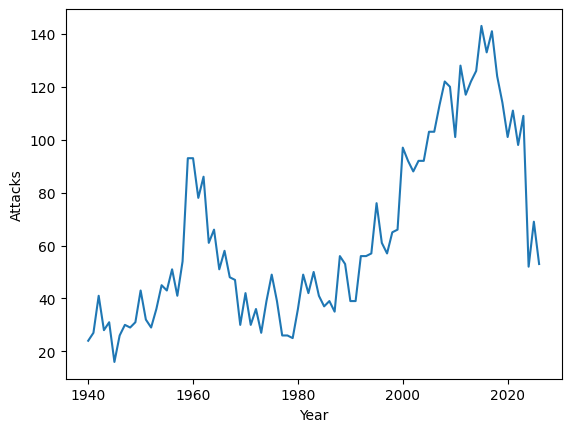

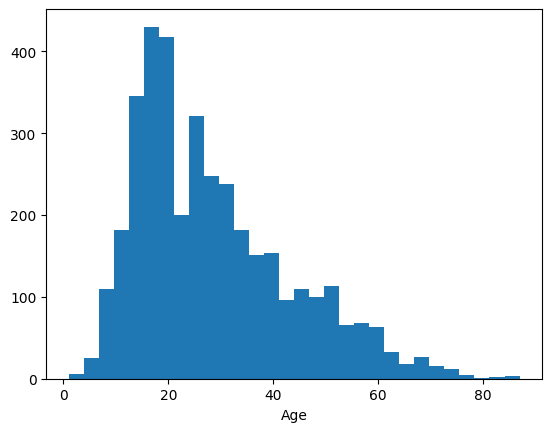

0.801461289869327
0.7394969790642124
Type
Unprovoked    5263
Unknown       1205
Provoked       649
Name: count, dtype: int64


In [ ]:
# Question 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel('GSAF5.xls')

#dropping columns with no values
df = df.drop(columns=['pdf','href formula', 'href', 'Case Number', 'Case Number.1', 'original order', 'Unnamed: 21', 'Unnamed: 22'])
df.head()

# cleaning the year - erplacing 0 with nan
df['Year'] = pd.to_numeric(df['Year'], errors='coerce').replace(0, np.nan)
print(df['Year'].min(), df['Year'].max(), df['Year'].isna().sum())

sharks = df[df['Year'] >= 1940].copy()

# displaying the year by year variations in attacks
per_year = sharks.groupby('Year').size()
plt.plot(per_year.index, per_year.values)
plt.xlabel('Year')
plt.ylabel('Attacks')
plt.show()

# cleaning the age column
sharks['Age'] = pd.to_numeric(sharks['Age'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
sharks.loc[(sharks['Age'] < 1) | (sharks['Age'] > 100), 'Age'] = np.nan

plt.hist(sharks['Age'].dropna(), bins=30)
plt.xlabel('Age')
plt.show()

#proportion male

count = 0
for male in df['Sex']:
    if male == "M":
        count += 1

# calculating proportion
proportion = count / len(df['Sex'])
print(proportion)

# cleaning type so it only takes correct syntax
df['Type'] = df['Type'].astype(str).str.upper().str.strip()
df['Type'] = df['Type'].replace('PROVOKED', 'Provoked')
df['Type'] = df['Type'].replace('UNPROVOKED', 'Unprovoked')
for type in df["Type"]:
    if type != "Provoked" and type != "Unprovoked":
        df['Type'] = df['Type'].replace(type, "Unknown")

# Calculate proportion of unprovoked attacks
type_proportions = df['Type'].value_counts(normalize=True)
proportion_unprovoked = type_proportions.get('Unprovoked', 0)
print(proportion_unprovoked)

print(df['Type'].value_counts())

I loaded the data with with read_excel instead of read_csv, and dropped any columns with no data at all. I then cleaned the year colum and displayed a plot of the variation. I then cleaned the age and plotted a histogram. next I calculated the proportion of men which came around ~80%. Lastly I cleaded the type column to only accept the correct syntax and calculated the proportion.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** a658de544c7359358f3ced50d839dedc64e2016f
- **AI tool and model used:** Claude Opus 5

### *Prompts used

1. I’m working on a data wrangling lab for my data science class. I’ve attached my notebook, the datasets, and some of our course materials. Can you look over what I did in Phase 1 for Q1 and Q2 and point out anything I should fix or improve? I’m mainly looking for issues with my code, how I cleaned the data, missing values, calculations, graphs, or my written conclusions. Don’t redo the whole lab for me, just give me a short numbered list of changes you’d recommend and why.
2. Can you take another look at those suggestions and make sure they actually fit the assignment and the datasets? Double check things like missing values, how I cleaned variables like Price, Year, and Age, and how I handled categorical variables. If any of your original suggestions were unnecessary or wrong, take them out. Then give me a final numbered list of the changes you still think I should make.

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Tighten the Q1.1 explanation, and prefer pd.to_numeric(..., errors='coerce') over astype(float).
Your answer of 0 missing is correct and I verified it. Two fixes: the $ strip is a no-op (this column has no dollar signs, only 181 values with thousands separators like 1,990), and astype(float) raises on the first bad string rather than letting you count it. Coercing to NaN is what actually lets you answer "how many missing values do you end up with" rather than inferring it from the absence of a crash. In the write-up, name the comma issue specifically, since that is what the hint points at.

2. Fix the Q1.2 conclusion. It says the opposite of what your own output shows.
You wrote that the data "used clean types and there weren't any missing values." In fact 9,848 of 12,925 values are missing, or 76.2%. This is the single biggest thing to correct.

3. Report the proportion the question asks for.
Your loop counts Yes/No responses, so 0.238 is the share present, not missing. Replace the loop with df['subject_injury'].isna().mean().

4. Actually handle the NAs, and answer "is this a concern" using the time pattern.
"Handling the NA's" is the graded verb here, so state your decision explicitly: keep them as missing rather than filling with No, because you cannot distinguish an uninjured subject from an unrecorded one. Then, for the pattern, check missingness by year in response_datetime. It runs 41% in 2016 and 35% in 2017, jumps to 72% in 2018, and hits 100% in 2019, 2020, and 2021. The field simply stopped being recorded, so every non-missing value comes from 2016 to 2018. That is a much stronger answer to "when are the data missing" than the raw crosstab alone.

5. Improve the crosstab and drop the small-n rows from your conclusions.
Put force_type on rows with normalize='index'. Two cautions on what you write up: Firearm (n=2), Less Lethal Projectile (n=3), and Baton (n=4) have rates that are pure noise, so do not describe them as patterns. And because of item 4, the raw force_type rates are partly confounded with time. If you restrict to 2016 to 2017, one real difference survives: Chemical Irritant is 82% missing versus 30% for Bodily Force and 3% for Taser. That is worth a sentence, and it means any injury rate you compute is biased by force type as well as by year.

6. The columns you dropped are not empty.
pdf, href formula, href, Case Number, Case Number.1, and original order each hold about 6,798 non-null values out of 7,117. Only Unnamed: 21 (1 value) and Unnamed: 22 (2 values) are effectively blank. Do the mechanical step with df.dropna(axis=1, how='all'), then drop the URL and ID columns as a separate step you justify as "not needed for this analysis." Your comment currently claims they had no values.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | modify  | Correctly identifies the missed logic in my code |
| 2 | Accept  | Must adjust my conclusion to handle the mistake in my logic |
| 3 | Accept  | Clarifies my respinse to the question |
| 4 | Accept  | This also clarifies the data in the table and is good practice |
| 5 | modify  | This is a better conclusion and more clear answer |
| 6 | Accept  | Correcting a mistake i made in the origional code |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.
# Question 1 part 1 solution

import pandas as pd

df = pd.read_csv('airbnb_hw.csv')

# checking what the messy values actually look like before converting anything
print(df['Price'].dtype)
print(df['Price'][df['Price'].str.contains(',')].head(3).tolist())
print('values with commas:', df['Price'].str.contains(',').sum())

# stripping the thousands separators and converting to a number.
# using to_numeric with errors='coerce' instead of astype(float) so that anything
# unexpected becomes NaN and gets counted, instead of raising and stopping the cell
df['Price'] = pd.to_numeric(df['Price'].str.replace(',', ''), errors='coerce')

print(df['Price'].dtype)

display(df)

# checking for any missing values
missing_price_values = df['Price'].isna().sum()
print('missing:', missing_price_values)
print(df['Price'].describe())

In [ ]:
# Question 1 part 2 solution

import pandas as pd

df = pd.read_csv('mn_police_use_of_force.csv')

# looking at every value the column actually takes, including the NAs
print(df['subject_injury'].value_counts(dropna=False))

# we leave the NAs as missing rather than filling them with "No", since an
# unrecorded outcome is not the same thing as no injury
missing_subject_injury = df['subject_injury'].isna().sum()
proportion_missing = df['subject_injury'].isna().mean()
print('missing count:', missing_subject_injury)
print('proportion missing:', round(proportion_missing, 3))

# checking when the data go missing
df['year'] = pd.to_datetime(df['response_datetime'], errors='coerce', utc=True).dt.year
by_year = df.groupby('year')['subject_injury'].agg(n='size', prop_missing=lambda s: s.isna().mean())
print(by_year.round(3))

# crosstabulating missingness against force type, as rates rather than raw counts
missing_by_force = pd.crosstab(df['force_type'], df['subject_injury'].isna(), normalize='index')
missing_by_force.columns = ['recorded', 'missing']
missing_by_force['n'] = df['force_type'].value_counts()
print(missing_by_force.sort_values('n', ascending=False).round(3))

# the same crosstab restricted to 2016-2017, when the field was still being filled in
early = df[df['year'] <= 2017]
early_missing = pd.crosstab(early['force_type'], early['subject_injury'].isna(), normalize='index')
early_missing.columns = ['recorded', 'missing']
early_missing['n'] = early['force_type'].value_counts()
print(early_missing.sort_values('n', ascending=False).round(3))

In [ ]:
# Question 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel('GSAF5.xls')

# checking which columns are actually empty before dropping anything
print(df.notna().sum())

# dropping columns that are genuinely empty. dropna removes anything fully blank,
# and Unnamed: 21 and Unnamed: 22 hold 1 and 2 stray values out of 7,117 rows,
# so we treat those as empty too
df = df.dropna(axis=1, how='all')
near_empty = [c for c in df.columns if df[c].notna().sum() < 5]
print('near empty columns:', near_empty)
df = df.drop(columns=near_empty)

# dropping the link and ID columns as a separate step. these are populated
# (roughly 6,800 values each), we just do not need them for this analysis
df = df.drop(columns=['pdf', 'href formula', 'href',
                      'Case Number', 'Case Number.1', 'original order'])

print(df.shape)
df.head()

### *Reflection on AI assistance
In your own words without generative AI.

Ulitmately I think that AI definitely improved my answer. I also think that it comes with its own limitations. For example, claude would suggest something unecessary or not important to the ultimate goal of this assignment. generally, I think that it increased the efficiency and end product significantly. I also think that it is very important to understand your code and what is happening behind the scenes before using AI. This way, you are able to completely understand the changes that AI is making to your code, and if it will actually improve the work. The changes that AI made were generally very intuitive and it was a great resource for refining my end result.